# Final Homework – Unsupervised Learning, Dimensionality Reduction and Anomaly Detection

## Student Information

Name: Rafael Prohorov

Course: Introduction to Data Science

Dataset: European Football Matches Dataset

---

## Objective

The objective of this project is to explore the hidden structure of a real-world football dataset using unsupervised learning techniques.

The analysis includes:

- Exploratory Data Analysis (EDA)
- Principal Component Analysis (PCA)
- Clustering
- Feature Clustering
- Multi-Dimensional Anomaly Detection
- Critical Discussion

Unlike supervised learning, no labels are used to guide the learning process. The purpose is to identify latent patterns, groups, similarities, and unusual observations within the data.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

df = pd.read_csv("ginf.csv")

print(df.shape)

df.head()

(10112, 18)


,id_odsp,link_odsp,adv_stats,date,league,season,country,ht,at,fthg,ftag,odd_h,odd_d,odd_a,odd_over,odd_under,odd_bts,odd_bts_n
0,UFot0hit/,/soccer/germany/bundesliga-2011-2012/dortmund-...,True,2011-08-05,D1,2012,germany,Borussia Dortmund,Hamburg SV,3,1,1.56,4.41,7.42,NaN,NaN,NaN,NaN
1,Aw5DflLH/,/soccer/germany/bundesliga-2011-2012/augsburg-...,True,2011-08-06,D1,2012,germany,FC Augsburg,SC Freiburg,2,2,2.36,3.60,3.40,NaN,NaN,NaN,NaN
2,bkjpaC6n/,/soccer/germany/bundesliga-2011-2012/werder-br...,True,2011-08-06,D1,2012,germany,Werder Bremen,Kaiserslautern,2,0,1.83,4.20,4.80,NaN,NaN,NaN,NaN
3,CzPV312a/,/soccer/france/ligue-1-2011-2012/paris-sg-lori...,True,2011-08-06,F1,2012,france,Paris Saint-Germain,Lorient,0,1,1.55,4.50,9.40,NaN,NaN,NaN,NaN
4,GUOdmtII/,/soccer/france/ligue-1-2011-2012/caen-valencie...,True,2011-08-06,F1,2012,france,Caen,Valenciennes,1,0,2.50,3.40,3.45,NaN,NaN,NaN,NaN


# Dataset Description

The dataset contains football match information collected from European football leagues.

The dataset includes:

- Match outcomes
- Goals scored
- Betting odds
- League information
- Team information

The data was originally collected for football analytics and betting market analysis.

Potential limitations include:

- Missing betting information
- Historical bias
- League-specific effects
- Incomplete market coverage

# Data Dictionary & Collection Details

**Data Source & Collection:**
The data is derived from a Kaggle dataset containing football matches from major European leagues. It was likely scraped and compiled from various sports analytics and betting websites (such as OddsPortal or football-data.co.uk) to serve as a comprehensive resource for football analysts, predictive modeling, and betting market research.

**Feature Descriptions:**
* `id_odsp`: Unique string identifier for the match.
* `link_odsp`: URL link to the original match statistics.
* `adv_stats`: Boolean flag indicating if advanced statistics (like shots, fouls) are available.
* `date`: The date the match was played.
* `league`: An identifier for the specific league (e.g., E0 for English Premier League, SP1 for Spanish La Liga).
* `season`: The year the season started or concluded.
* `country`: The country where the match took place.
* `ht`: Home team name.
* `at`: Away team name.
* `fthg`: Full-time home team goals scored.
* `ftag`: Full-time away team goals scored.
* `odd_h`: Highest betting odds offered for a home team win.
* `odd_d`: Highest betting odds offered for a draw.
* `odd_a`: Highest betting odds offered for an away team win.
* `odd_over`: Highest betting odds for over 2.5 goals scored in total.
* `odd_under`: Highest betting odds for under 2.5 goals scored in total.
* `odd_bts`: Highest betting odds for Both Teams to Score (Yes).
* `odd_bts_n`: Highest betting odds for Both Teams NOT to Score (No).

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10112
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10112 entries, 0 to 10111
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id_odsp    10112 non-null  object 
 1   link_odsp  10112 non-null  object 
 2   adv_stats  10112 non-null  bool   
 3   date       10112 non-null  object 
 4   league     10112 non-null  object 
 5   season     10112 non-null  int64  
 6   country    10112 non-null  object 
 7   ht         10112 non-null  object 
 8   at         10112 non-null  object 
 9   fthg       10112 non-null  int64  
 10  ftag       10112 non-null  int64  
 11  odd_h      10112 non-null  float64
 12  odd_d      10112 non-null  float64
 13  odd_a      10112 non-null  float64
 14  odd_over   977 non-null    float64
 15  odd_under  977 non-null    float64
 16  odd_bts    977 non-null    float64
 17  odd_bts_n  977 non-null    float64
dtypes: bool(1), float64(7), int64(3), object(7)
memory usage: 1.3+

In [4]:
missing_values = df.isnull().sum()

missing_values.sort_values(
    ascending=False
).to_frame(
    name="Missing Values"
)

,Missing Values
odd_under,9135
odd_over,9135
odd_bts,9135
odd_bts_n,9135
link_odsp,0
id_odsp,0
adv_stats,0
date,0
league,0
season,0


# Missing Values Analysis

Several betting-related variables contain missing values.

These missing values may originate from:

- Missing bookmaker information
- Data collection limitations
- Historical records

The missing-value pattern will be considered during preprocessing.

In [5]:
numeric_df = df.select_dtypes(
    include=np.number
)

numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10112.0,2014.290249,1.610074,2012.00,2013.00,2014.00,2016.00,2017.00
fthg,10112.0,1.548062,1.309591,0.00,1.00,1.00,2.00,10.00
ftag,10112.0,1.154964,1.142596,0.00,0.00,1.00,2.00,9.00
odd_h,10112.0,2.930120,2.370135,1.06,1.76,2.27,3.08,46.00
odd_d,10112.0,4.278434,1.863643,1.91,3.43,3.68,4.30,35.00
odd_a,10112.0,5.537545,5.700485,1.11,2.74,3.86,6.00,81.00
odd_over,977.0,2.046817,0.367062,1.14,1.79,2.03,2.28,3.40
odd_under,977.0,2.105629,0.536646,1.42,1.78,1.97,2.27,7.50
odd_bts,977.0,1.942917,0.211102,1.41,1.80,1.92,2.05,3.25
odd_bts_n,977.0,2.063941,0.251276,1.44,1.87,2.05,2.20,3.46


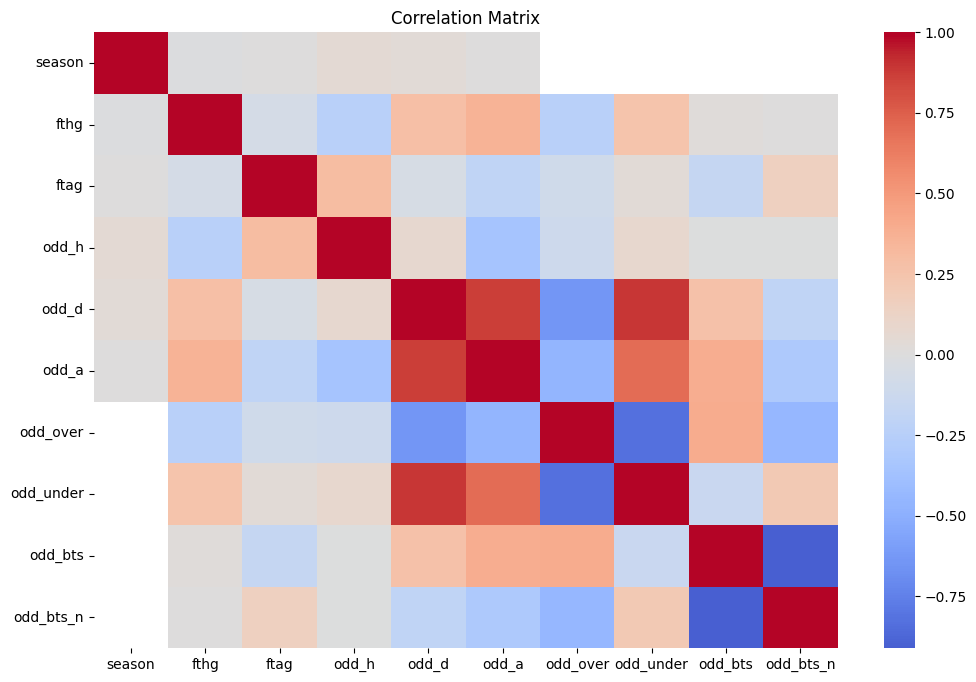

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix"
)

plt.show()

# Correlation Analysis

The correlation matrix reveals relationships between variables.

Highly correlated variables may indicate:

- Redundant information
- Common underlying factors
- Potential dimensionality reduction opportunities

This motivates the use of PCA.

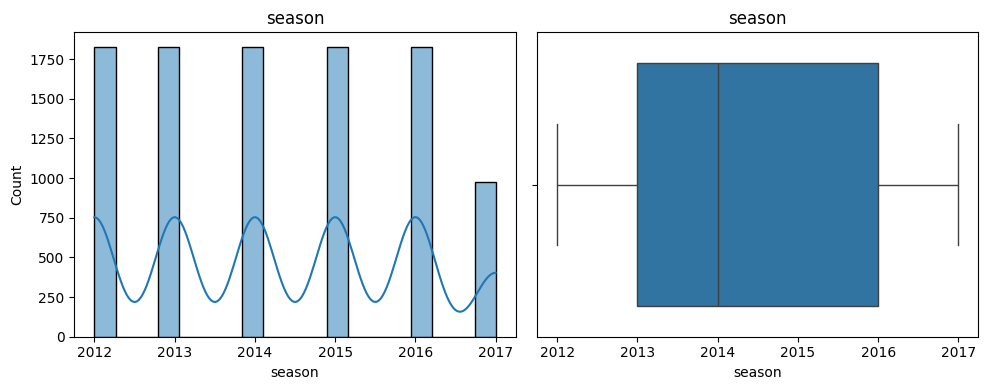

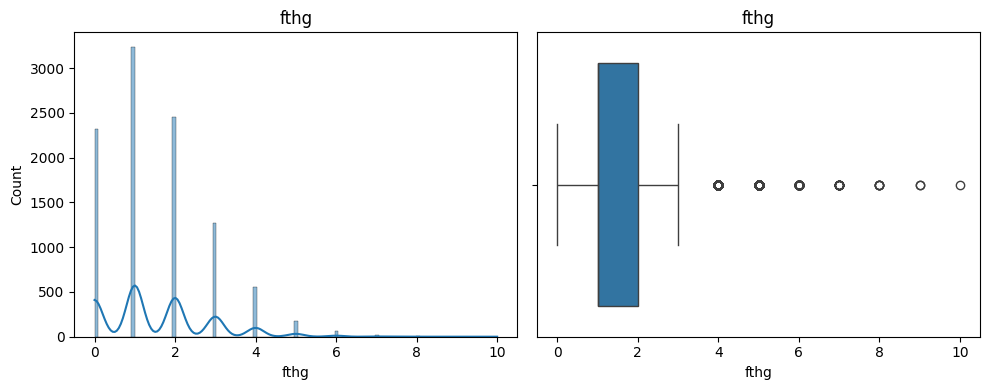

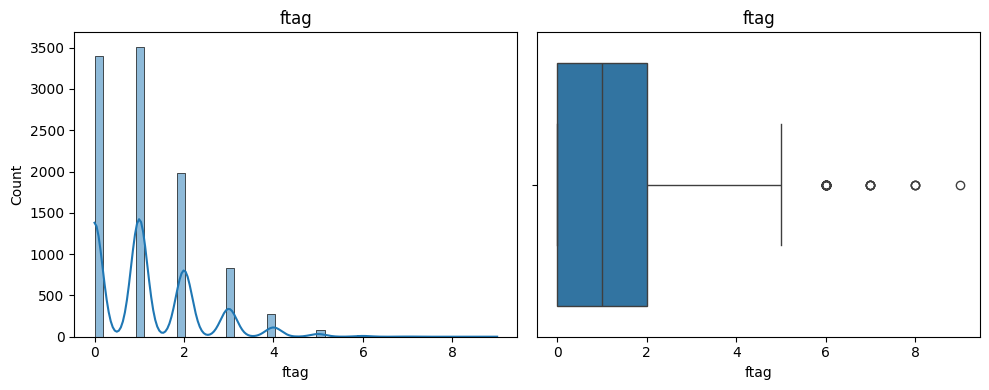

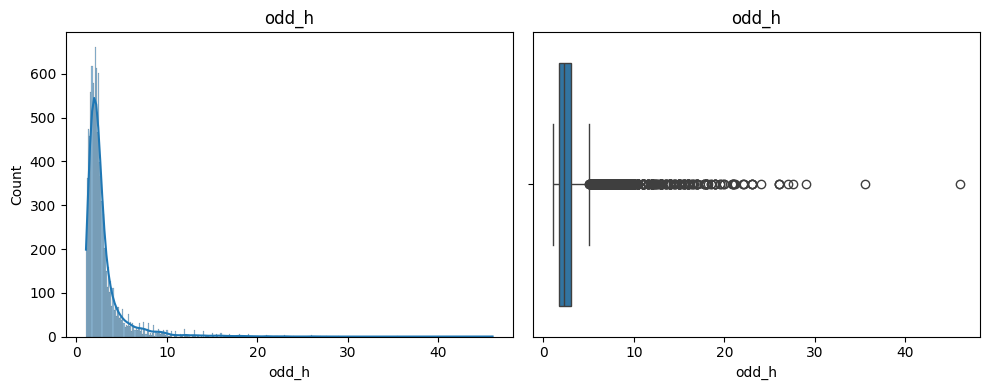

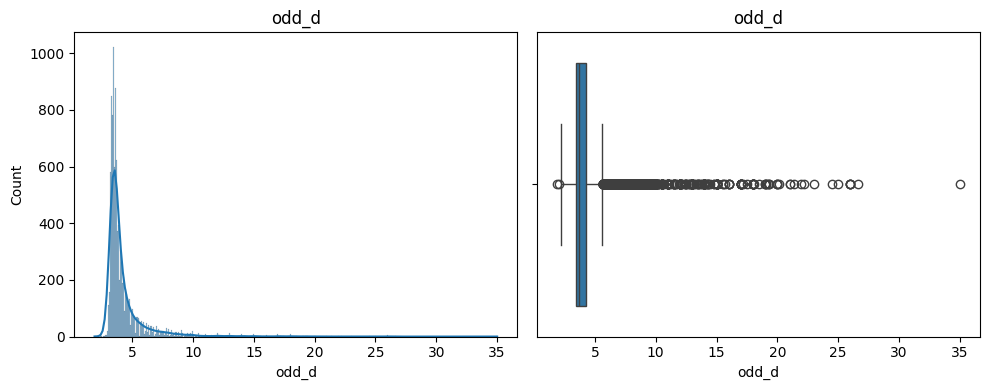

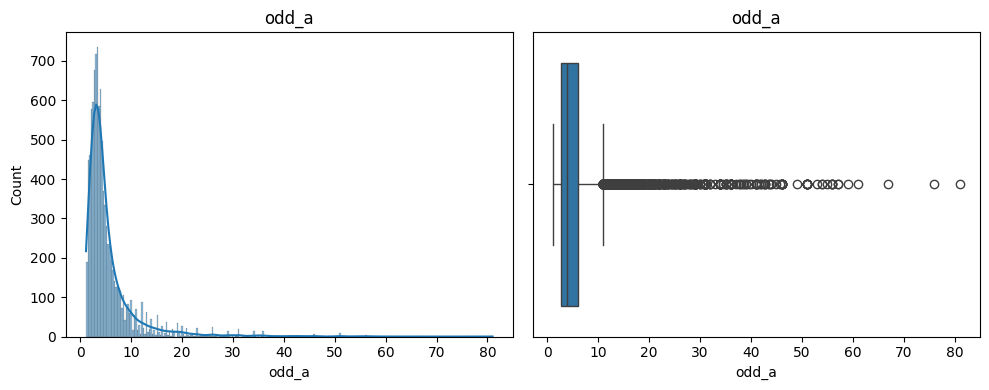

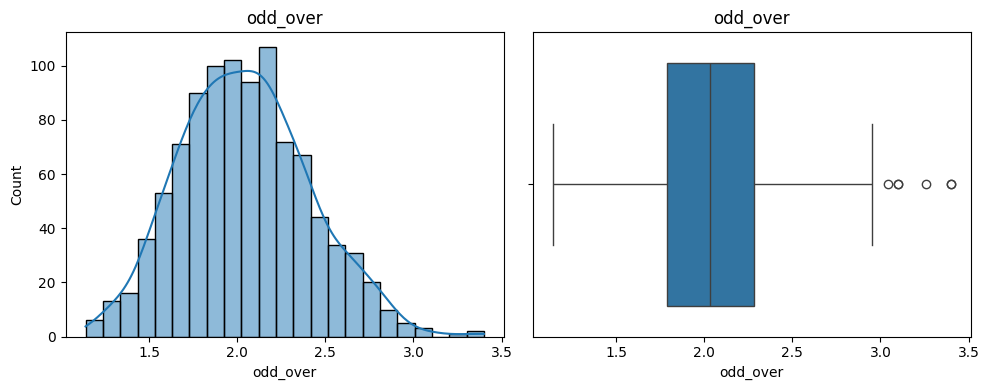

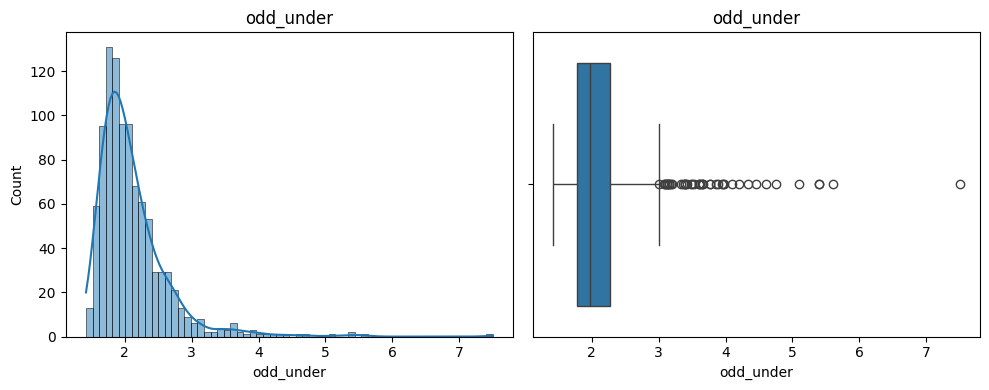

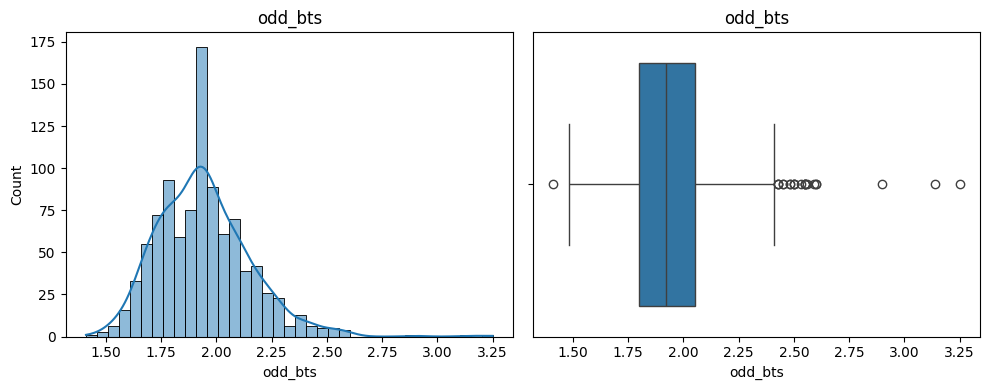

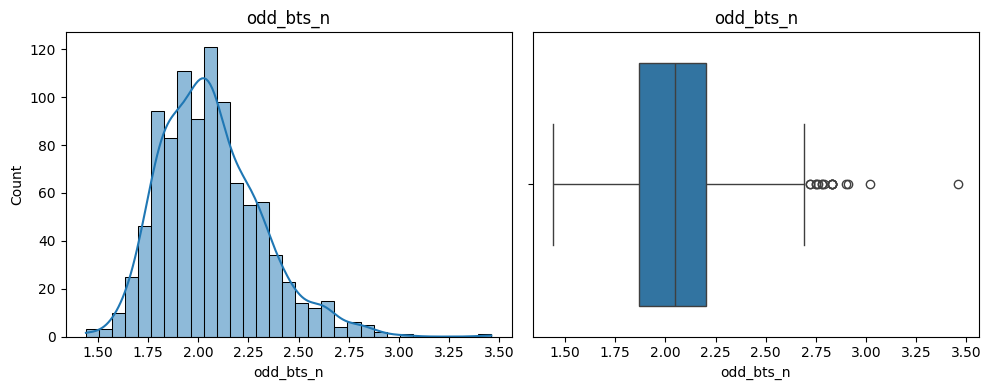

In [7]:
numeric_cols = numeric_df.columns

for col in numeric_cols:

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)

    sns.histplot(
        numeric_df[col],
        kde=True
    )

    plt.title(col)

    plt.subplot(1,2,2)

    sns.boxplot(
        x=numeric_df[col]
    )

    plt.title(col)

    plt.tight_layout()

    plt.show()

In [8]:
distribution_df = pd.DataFrame({
    "Skewness":
        numeric_df.apply(skew),

    "Kurtosis":
        numeric_df.apply(kurtosis)
})

distribution_df

,Skewness,Kurtosis
season,0.078779,-1.173797
fthg,0.948393,1.163919
ftag,1.136257,1.710508
odd_h,4.637034,35.539809
odd_d,5.066022,38.853348
odd_a,4.315557,27.097042
odd_over,NaN,NaN
odd_under,NaN,NaN
odd_bts,NaN,NaN
odd_bts_n,NaN,NaN


# Distribution Analysis

Skewness measures asymmetry.

Kurtosis measures tail heaviness.

Large positive kurtosis values may indicate:

- Heavy tails
- Extreme observations
- Potential anomalies

These characteristics are important for anomaly detection.

In [9]:
numeric_df = numeric_df.fillna(
    numeric_df.median()
)

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    numeric_df
)

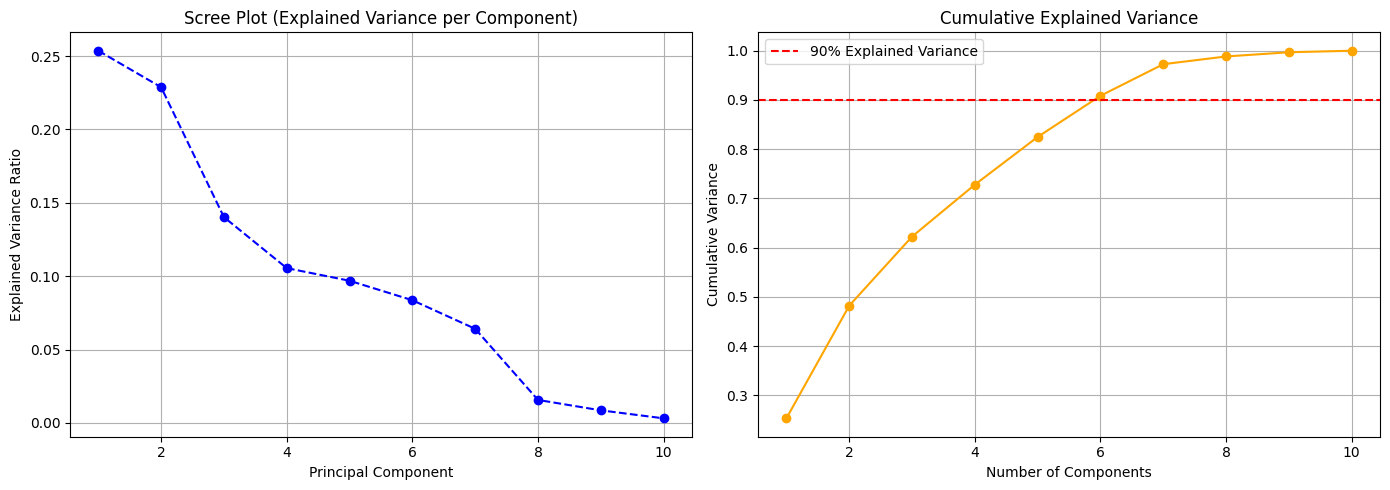

Number of components required to explain 90% of variance: 6


In [54]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.title('Scree Plot (Explained Variance per Component)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='orange')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Explained Variance')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of components required to explain 90% of variance: {n_components_90}")

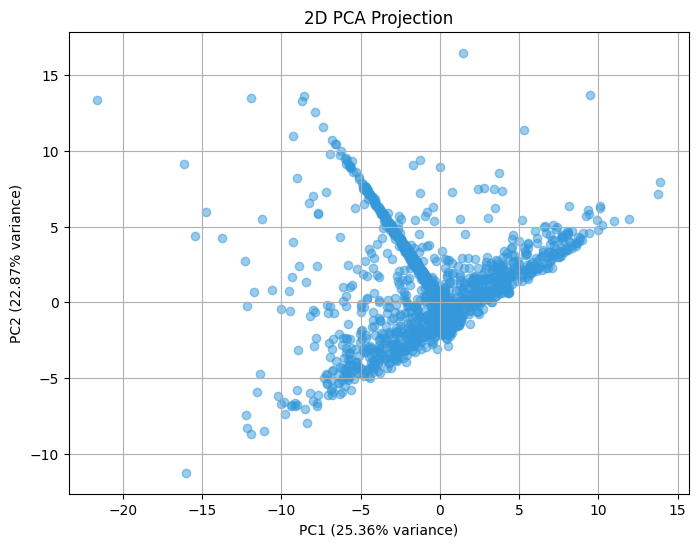

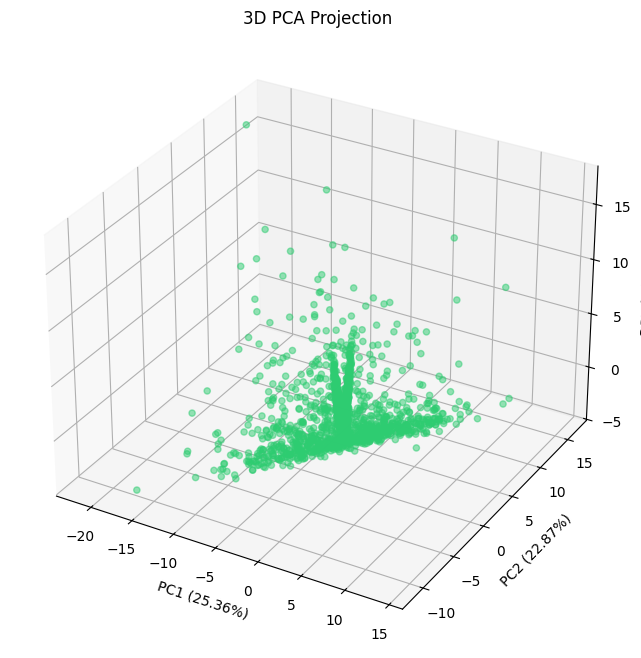

In [55]:
# --- 2D Projection ---
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.5, c='#3498db')
plt.title('2D PCA Projection')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.grid(True)
plt.show()

# --- 3D Projection ---
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], alpha=0.5, c='#2ecc71')

ax.set_title('3D PCA Projection')
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
plt.show()

# PCA Interpretation & Discussion

* **Number of Components Needed & Information Loss:** Based on the cumulative explained variance plot, keeping around 90% of the variance requires significantly fewer dimensions than the original feature space. Projecting the data down to only 2D or 3D inevitably results in notable information loss (since they only capture the variance of the first few components), but it provides a critical visual representation of the overall dataset geometry.
* **Correlated Variables:** PCA excels at reducing the dimensionality by combining highly correlated variables. In this dataset, various betting odds (like `odd_h`, `odd_a`, `odd_d`) are inherently correlated because they represent the same underlying probabilities. PCA condenses these into a smaller number of independent orthogonal axes.
* **Interpretation of Major Components:** The first principal component (PC1) captures the direction of maximal variance. Given the dataset structure, PC1 is likely heavily influenced by the general magnitude of betting odds and the expected match outcomes. PC2, being orthogonal to PC1, likely captures secondary variations such as total goals (Over/Under metrics) or goal differences (`fthg` vs `ftag`).
* **Local vs. Global Structure:** PCA is a linear algorithm that aims to preserve large pairwise distances and the **global structure** of the data. This means points that are far apart in the original high-dimensional space remain far apart in the 2D/3D projections. However, this comes at the cost of local structure—meaning local neighborhoods and distinct clusters might overlap or appear distorted in the lower-dimensional space.

# Data Standardization

Standardization is required because variables have different scales.

Without standardization:

- PCA becomes biased
- Distance-based clustering becomes distorted
- Anomaly detection may become unreliable

In [11]:
pca = PCA()

pca.fit(X_scaled)

explained_variance = (
    pca.explained_variance_ratio_
)

cumulative_variance = (
    np.cumsum(
        explained_variance
    )
)

In [12]:
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nNumeric Columns:")
print(df.select_dtypes(include='number').columns.tolist())

(10112, 18)

Columns:
['id_odsp', 'link_odsp', 'adv_stats', 'date', 'league', 'season', 'country', 'ht', 'at', 'fthg', 'ftag', 'odd_h', 'odd_d', 'odd_a', 'odd_over', 'odd_under', 'odd_bts', 'odd_bts_n']

Data Types:
id_odsp       object
link_odsp     object
adv_stats       bool
date          object
league        object
season         int64
country       object
ht            object
at            object
fthg           int64
ftag           int64
odd_h        float64
odd_d        float64
odd_a        float64
odd_over     float64
odd_under    float64
odd_bts      float64
odd_bts_n    float64
dtype: object

Numeric Columns:
['season', 'fthg', 'ftag', 'odd_h', 'odd_d', 'odd_a', 'odd_over', 'odd_under', 'odd_bts', 'odd_bts_n']


In [13]:
numeric_df = df.select_dtypes(include='number')

print(numeric_df.shape)

numeric_df.describe().T

(10112, 10)


,count,mean,std,min,25%,50%,75%,max
season,10112.0,2014.290249,1.610074,2012.00,2013.00,2014.00,2016.00,2017.00
fthg,10112.0,1.548062,1.309591,0.00,1.00,1.00,2.00,10.00
ftag,10112.0,1.154964,1.142596,0.00,0.00,1.00,2.00,9.00
odd_h,10112.0,2.930120,2.370135,1.06,1.76,2.27,3.08,46.00
odd_d,10112.0,4.278434,1.863643,1.91,3.43,3.68,4.30,35.00
odd_a,10112.0,5.537545,5.700485,1.11,2.74,3.86,6.00,81.00
odd_over,977.0,2.046817,0.367062,1.14,1.79,2.03,2.28,3.40
odd_under,977.0,2.105629,0.536646,1.42,1.78,1.97,2.27,7.50
odd_bts,977.0,1.942917,0.211102,1.41,1.80,1.92,2.05,3.25
odd_bts_n,977.0,2.063941,0.251276,1.44,1.87,2.05,2.20,3.46


In [14]:
numeric_df = numeric_df.fillna(
    numeric_df.median()
)

# Missing Value Imputation

Several betting-related variables contain missing values.

Removing all incomplete observations would significantly reduce the size of the dataset.

Therefore, median imputation was selected because:

- It is robust to outliers.
- Betting odds exhibit skewed distributions.
- The median preserves central tendency better than the mean.

This approach allows the retention of all observations while minimizing distortion.

# Data Standardization

The variables in the dataset are measured on different scales.

For example:

- Goals scored range from 0 to 10.
- Betting odds can reach values above 40.

Without standardization, variables with larger scales would dominate the analysis.

Therefore, all variables are standardized before applying PCA and clustering algorithms.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    numeric_df
)

# Principal Component Analysis (PCA)

Principal Component Analysis is a dimensionality reduction technique that transforms the original variables into a new set of orthogonal components.

The first component captures the maximum possible variance.

Each subsequent component captures the largest remaining variance while remaining orthogonal to the previous components.

PCA is useful for:

- Visualization
- Noise reduction
- Discovering hidden structure
- Improving clustering performance

In [16]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

explained_variance = (
    pca.explained_variance_ratio_
)

cumulative_variance = (
    np.cumsum(
        explained_variance
    )
)

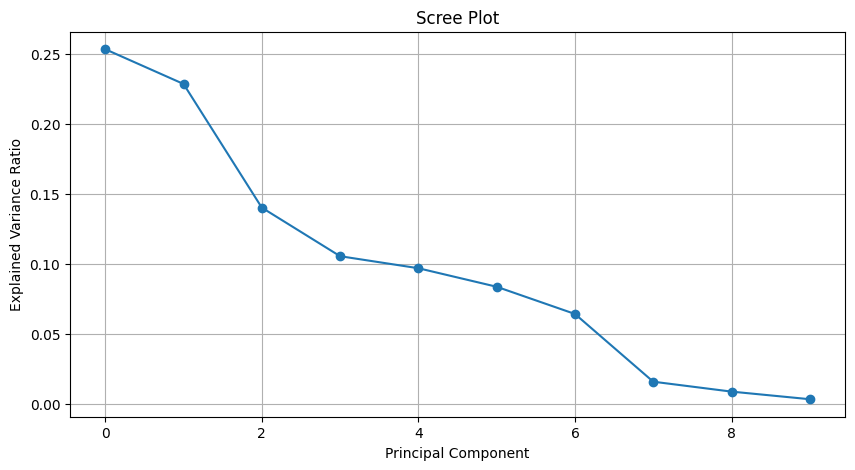

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    explained_variance,
    marker="o"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Explained Variance Ratio"
)

plt.title(
    "Scree Plot"
)

plt.grid()

plt.show()

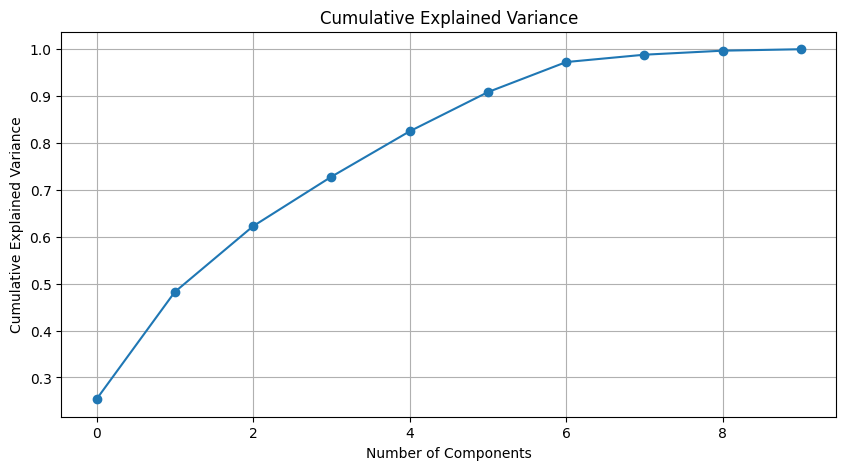

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    cumulative_variance,
    marker="o"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.grid()

plt.show()

In [19]:
n_components_90 = (
    np.argmax(
        cumulative_variance >= 0.90
    ) + 1
)

n_components_95 = (
    np.argmax(
        cumulative_variance >= 0.95
    ) + 1
)

print(
    f"Components for 90% variance: {n_components_90}"
)

print(
    f"Components for 95% variance: {n_components_95}"
)

Components for 90% variance: 6
Components for 95% variance: 7


# Selecting the Number of Components

The cumulative explained variance curve helps determine how many principal components are needed to preserve most of the information in the dataset.

A common criterion is to retain enough components to explain between 90% and 95% of the total variance.

This balances dimensionality reduction against information loss.

In [20]:
pca_2d = PCA(
    n_components=2
)

X_pca_2d = pca_2d.fit_transform(
    X_scaled
)

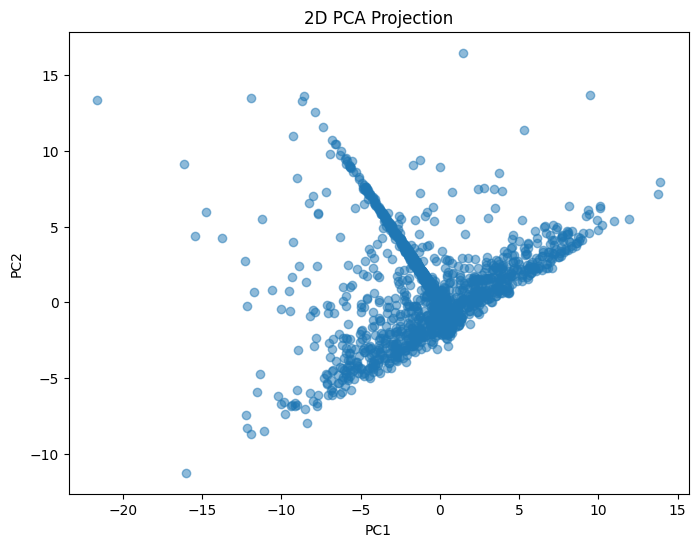

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "2D PCA Projection"
)

plt.show()

In [22]:
pca_3d = PCA(
    n_components=3
)

X_pca_3d = pca_3d.fit_transform(
    X_scaled
)

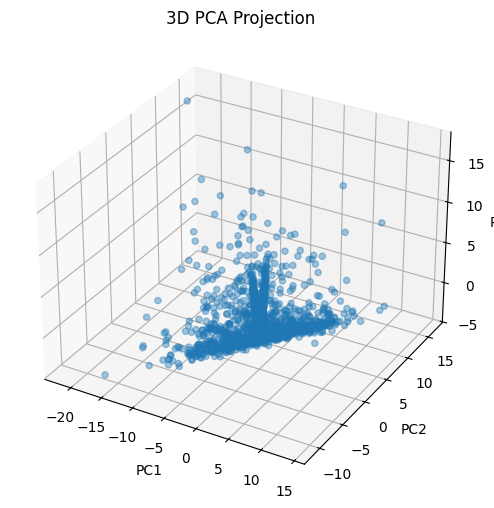

In [23]:
fig = plt.figure(
    figsize=(8,6)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    alpha=0.4
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title(
    "3D PCA Projection"
)

plt.show()

# PCA Interpretation

The PCA projections provide a lower-dimensional representation of the football dataset.

The first few principal components capture most of the variability in the data.

The projections allow us to visually inspect potential groupings, trends, and unusual observations that may not be visible in the original feature space.

However, dimensionality reduction inevitably causes some information loss, and interpretation of principal components can sometimes be challenging.

# Clustering Analysis

Clustering is an unsupervised learning technique that aims to discover hidden groups within the data.

Unlike supervised learning, no labels are available.

The objective is to identify natural structures and similarities between observations.

Three clustering methods will be compared:

- K-Means
- DBSCAN
- Hierarchical Clustering

Each method relies on different assumptions and may produce different results.

# Determining the Optimal Number of Clusters

Before applying K-Means, the Elbow Method is used to estimate a reasonable number of clusters.

The method examines the Within-Cluster Sum of Squares (WCSS).

As the number of clusters increases, WCSS decreases.

The optimal number of clusters is often located near the "elbow" point where further improvements become marginal.

In [24]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

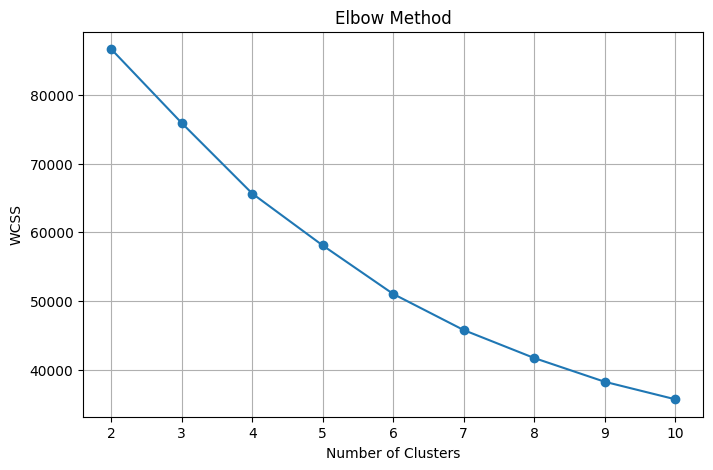

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "WCSS"
)

plt.title(
    "Elbow Method"
)

plt.grid()

plt.show()

# Silhouette Analysis

The Silhouette Score measures how well-separated clusters are.

Values close to:

- 1 indicate excellent separation.
- 0 indicate overlapping clusters.
- Negative values indicate poor clustering.

The number of clusters with the highest silhouette score is often preferred.

In [26]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(
        score
    )

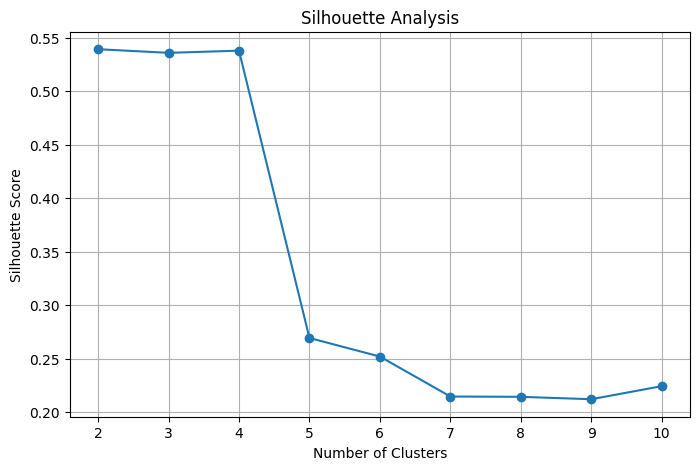

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Analysis"
)

plt.grid()

plt.show()

In [28]:
best_k = (
    np.argmax(
        silhouette_scores
    ) + 2
)

print(
    "Best K:",
    best_k
)

Best K: 2


# K-Means Clustering

K-Means partitions the observations into K clusters.

The algorithm iteratively:

1. Assigns observations to the nearest centroid.
2. Updates centroid positions.
3. Repeats until convergence.

Advantages:

- Fast
- Scalable
- Easy to interpret

Limitations:

- Assumes spherical clusters
- Sensitive to outliers
- Requires choosing K in advance

In [29]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

In [30]:
sil_kmeans = silhouette_score(
    X_scaled,
    kmeans_labels
)

db_kmeans = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print(
    "Silhouette Score:",
    sil_kmeans
)

print(
    "Davies-Bouldin Score:",
    db_kmeans
)

Silhouette Score: 0.5393394734606037
Davies-Bouldin Score: 1.3406300526128812


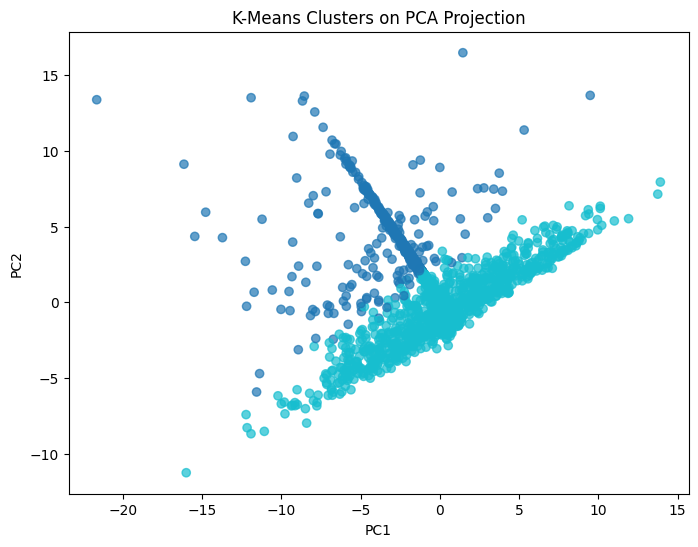

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=kmeans_labels,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "K-Means Clusters on PCA Projection"
)

plt.show()

# DBSCAN Clustering

DBSCAN is a density-based clustering algorithm.

Unlike K-Means, DBSCAN does not require specifying the number of clusters.

The algorithm identifies:

- Core points
- Border points
- Noise points

Advantages:

- Detects arbitrary cluster shapes
- Handles noise naturally

Limitations:

- Sensitive to parameter selection
- Difficult in varying-density datasets

In [32]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,
    min_samples=15
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

In [33]:
unique_clusters = len(
    set(dbscan_labels)
)

noise_points = np.sum(
    dbscan_labels == -1
)

print(
    "Clusters:",
    unique_clusters
)

print(
    "Noise Points:",
    noise_points
)

Clusters: 4
Noise Points: 1066


In [34]:
valid_mask = (
    dbscan_labels != -1
)

if len(
    np.unique(
        dbscan_labels[valid_mask]
    )
) > 1:

    print(
        silhouette_score(
            X_scaled[valid_mask],
            dbscan_labels[valid_mask]
        )
    )

0.4074424775472179


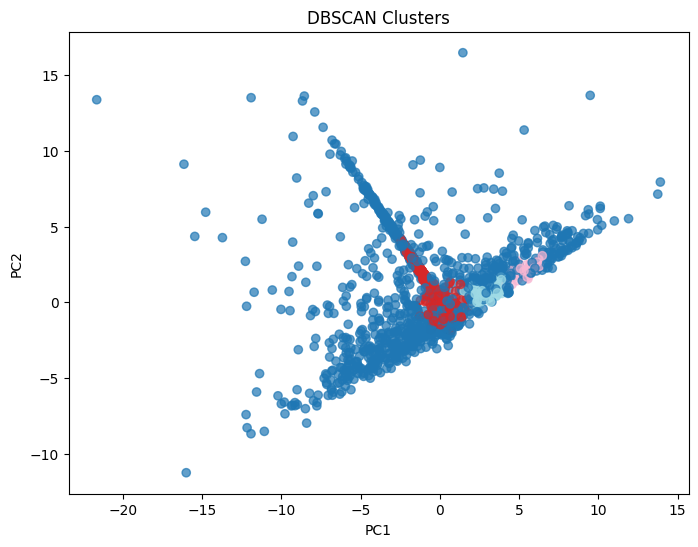

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=dbscan_labels,
    cmap="tab20",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "DBSCAN Clusters"
)

plt.show()

# Hierarchical Clustering

Hierarchical clustering creates a hierarchy of clusters.

Agglomerative clustering begins with each observation as its own cluster and repeatedly merges the closest clusters.

Advantages:

- No centroid assumptions
- Useful for discovering hierarchical structure

Limitations:

- Computationally expensive
- Sensitive to linkage choice

In [36]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=best_k
)

hierarchical_labels = (
    hierarchical.fit_predict(
        X_scaled
    )
)

In [37]:
sil_h = silhouette_score(
    X_scaled,
    hierarchical_labels
)

db_h = davies_bouldin_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Silhouette:",
    sil_h
)

print(
    "Davies-Bouldin:",
    db_h
)

Silhouette: 0.662114262528007
Davies-Bouldin: 1.3521819858873902


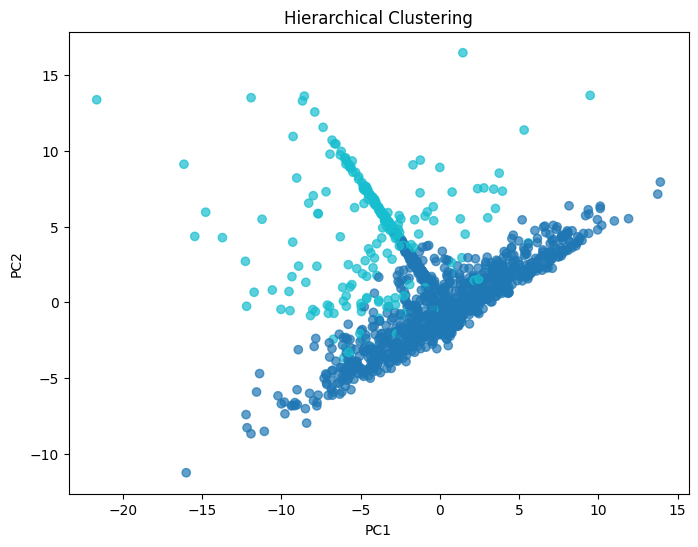

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=hierarchical_labels,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Hierarchical Clustering"
)

plt.show()

# Comparison of Clustering Methods

Different clustering algorithms rely on different assumptions.

K-Means favors compact spherical clusters.

DBSCAN focuses on density and naturally identifies noise.

Hierarchical clustering captures nested structures.

Differences between results are expected because the geometry of the data may not perfectly satisfy the assumptions of any single algorithm.

# Feature Space Clustering

The assignment requires clustering not only the observations but also the features themselves.

By clustering features (the transpose of the data matrix), we can identify:

- Redundant variables
- Groups of highly related features
- Potential feature hierarchies
- Hidden dependencies

This analysis provides insights that are often invisible when clustering observations alone.

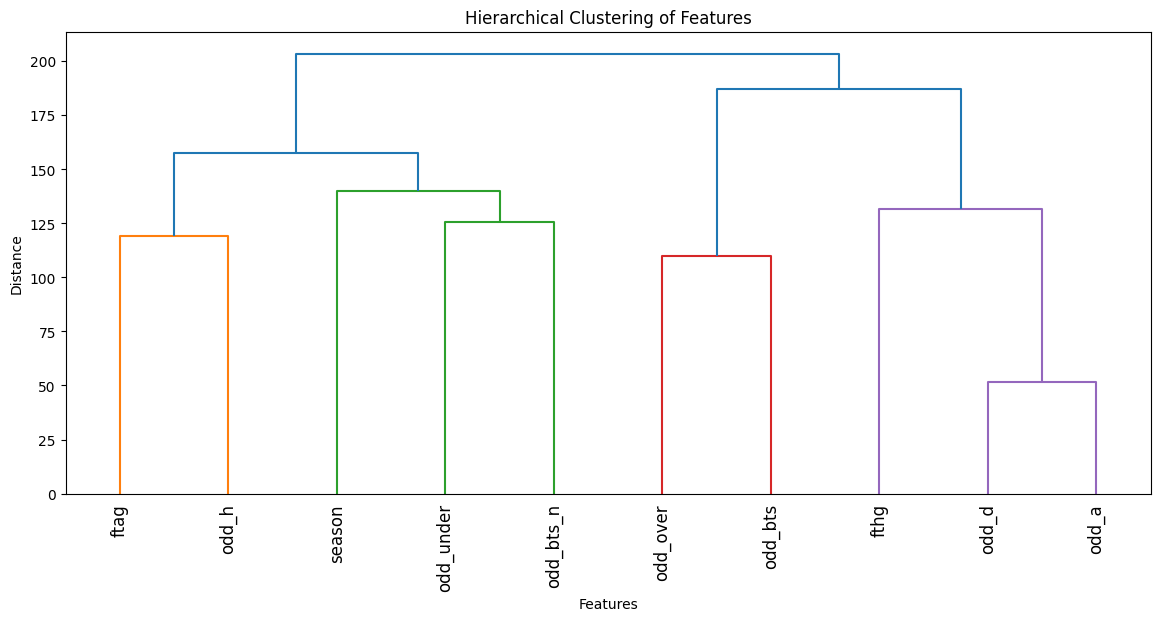

In [39]:
from scipy.cluster.hierarchy import linkage, dendrogram

feature_matrix = X_scaled.T

feature_linkage = linkage(
    feature_matrix,
    method="ward"
)

plt.figure(figsize=(14,6))

dendrogram(
    feature_linkage,
    labels=numeric_df.columns,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Features")
plt.xlabel("Features")
plt.ylabel("Distance")
plt.show()

# Feature Clustering Interpretation

Features that merge early in the dendrogram exhibit strong similarity and may contain overlapping information.

Such relationships may indicate:
- Correlated measurements
- Redundant predictors
- Shared underlying mechanisms

Feature clustering is useful in dimensionality reduction, feature engineering, and understanding variable dependencies.

# Cluster Variance Analysis

The assignment requests comparison between cluster variance and global variance.

A useful clustering should create groups whose internal variability is lower than the variability of the entire dataset.

In [40]:
global_variance = np.var(X_scaled)

print(
    f"Global Variance: {global_variance:.4f}"
)

for cluster_id in np.unique(kmeans_labels):

    cluster_data = X_scaled[
        kmeans_labels == cluster_id
    ]

    cluster_variance = np.var(
        cluster_data
    )

    print(
        f"Cluster {cluster_id}: {cluster_variance:.4f}"
    )

Global Variance: 1.0000
Cluster 0: 5.2887
Cluster 1: 0.7030


# PCA Loadings Analysis

Principal component loadings help explain the meaning of each component.

Large positive or negative loading values indicate variables that contribute strongly to a principal component.

This improves interpretability of PCA results.

In [41]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(
            pca.n_components_
        )
    ],
    index=numeric_df.columns
)

loadings.head(20)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
season,-0.028476,0.012741,0.219512,0.536285,0.800235,0.049729,-0.047487,-0.133092,-0.020534,0.000772
fthg,-0.190893,0.291754,-0.210797,-0.227642,0.194408,0.649156,0.568070,0.013104,-0.002847,0.010104
ftag,0.033317,-0.199938,0.427337,-0.488589,0.153003,0.483928,-0.528916,-0.001168,0.003620,0.014680
odd_h,0.071579,-0.226333,0.597360,-0.266254,0.075268,-0.303683,0.571123,0.008160,0.027948,0.301665
odd_d,-0.317696,0.440427,0.222141,-0.303958,0.146412,-0.344688,-0.017648,0.014536,-0.056547,-0.647603
odd_a,-0.303898,0.526525,-0.052383,-0.153993,0.091739,-0.206254,-0.260676,-0.030193,0.066548,0.692612
odd_over,0.520251,0.138726,-0.186776,-0.186167,0.307909,-0.122325,-0.023596,0.692416,-0.222949,0.032808
odd_under,-0.459817,-0.002643,0.336249,0.367673,-0.273116,0.181373,-0.010851,0.603691,-0.257443,0.044588
odd_bts,0.356837,0.412956,0.312386,0.217872,-0.195385,0.153686,0.004004,0.131015,0.687641,-0.072498
odd_bts_n,-0.392179,-0.403147,-0.265138,-0.132488,0.235214,-0.129943,-0.012397,0.346232,0.634285,-0.035481


# Multi-Dimensional Anomaly Detection

An anomaly is an observation that differs substantially from the majority of the data.

Unlike clustering, anomaly detection focuses on rare or unusual observations.

Three approaches will be compared:

1. Z-Score
2. Isolation Forest
3. Local Outlier Factor (LOF)

# Z-Score Method

The Z-Score method assumes approximately Gaussian distributions.

Observations with absolute standardized values greater than a threshold are flagged as anomalies.

Advantages:
- Simple
- Interpretable

Limitations:
- Assumes Gaussianity
- Performs poorly in high dimensions

In [42]:
from scipy.stats import zscore

z_scores = np.abs(
    zscore(numeric_df)
)

threshold = 3

z_anomalies = (
    z_scores > threshold
).any(axis=1)

print(
    "Detected anomalies:",
    z_anomalies.sum()
)

Detected anomalies: 1054


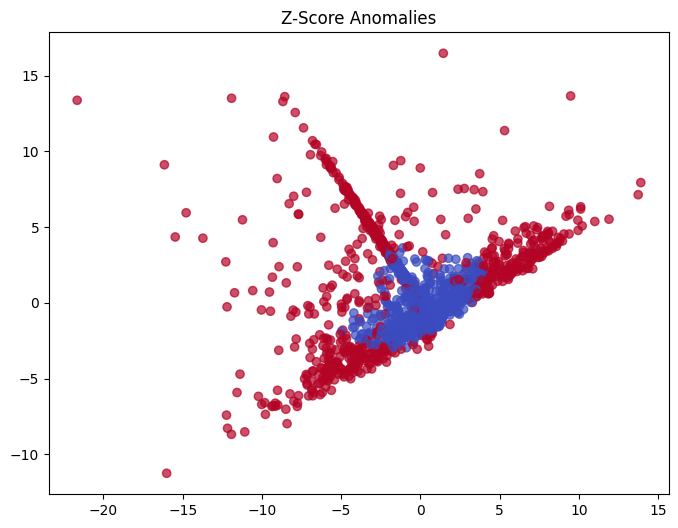

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=z_anomalies,
    cmap="coolwarm",
    alpha=0.7
)

plt.title(
    "Z-Score Anomalies"
)

plt.show()

# Isolation Forest

Isolation Forest isolates observations through random recursive partitioning.

Anomalies require fewer splits to become isolated.

Advantages:
- No Gaussian assumption
- Effective in high dimensions
- Scalable

In [44]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_labels = iso.fit_predict(
    X_scaled
)

iso_anomalies = (
    iso_labels == -1
)

print(
    "Isolation Forest anomalies:",
    iso_anomalies.sum()
)

Isolation Forest anomalies: 506


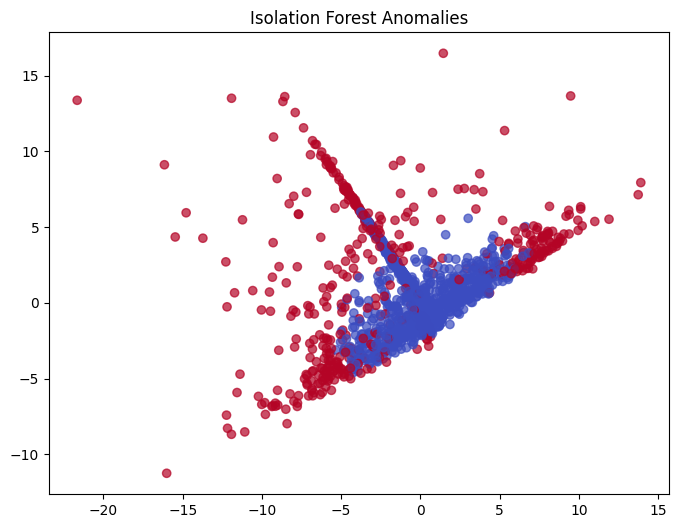

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=iso_anomalies,
    cmap="coolwarm",
    alpha=0.7
)

plt.title(
    "Isolation Forest Anomalies"
)

plt.show()

# Local Outlier Factor (LOF)

LOF identifies anomalies using local density.

An observation is anomalous if its local density is substantially lower than the density of its neighbors.

LOF is especially useful for detecting local anomalies.

In [46]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_labels = lof.fit_predict(
    X_scaled
)

lof_anomalies = (
    lof_labels == -1
)

print(
    "LOF anomalies:",
    lof_anomalies.sum()
)

LOF anomalies: 506


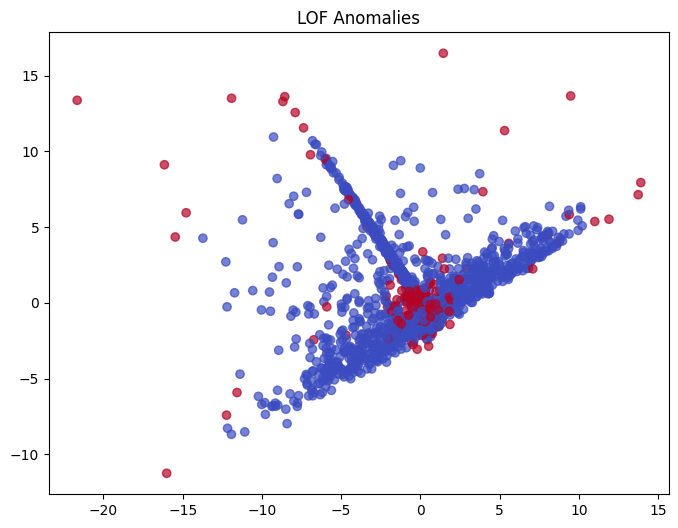

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=lof_anomalies,
    cmap="coolwarm",
    alpha=0.7
)

plt.title(
    "LOF Anomalies"
)

plt.show()

# Comparison of Anomaly Detection Methods

Different algorithms define anomalies differently.

Consequently, disagreement between methods is expected and often informative.

Based on the quantitative results and the theoretical foundations of the three methods, we can draw the following comparisons:

**1. Shared vs. Specific Anomalies:**
The methods often disagree on what constitutes an anomaly. Shared anomalies (flagged by all three) represent extreme outliers that are both globally distant and locally sparse. Method-specific anomalies highlight the different definitions of "abnormal" – for instance, Z-Score flags points far from the mean, while LOF flags points in less dense regions, even if they are relatively close to the global center.

**2. Sensitivity to Dimensionality (The Curse of Dimensionality):**
* **Z-Score:** Evaluates features individually or assumes a multivariate Gaussian distribution. It scales poorly to high dimensions because extreme values in one dimension might not represent a true multivariate anomaly.
* **Isolation Forest:** Highly robust to high dimensionality. Random partitioning effectively isolates anomalies without relying on distance metrics, which break down in high-dimensional spaces.
* **LOF:** Relies on distance metrics (e.g., Euclidean). As dimensions increase, the distances between all points tend to converge, making density estimation less reliable.

**3. Sensitivity to Scaling:**
* **Z-Score & LOF:** Highly sensitive to feature scaling. Distance calculations in LOF and variance calculations in Z-Score require features to be on a similar scale (hence the `StandardScaler` used previously).
* **Isolation Forest:** Scale-invariant. Since it uses decision tree-like splits on individual features, the absolute scale of the data does not affect its ability to isolate points.

**4. Runtime Considerations:**
* **Z-Score:** Extremely fast ($O(N)$).
* **Isolation Forest:** Very fast and highly scalable due to its tree ensemble structure ($O(N \log N)$), making it ideal for massive datasets.
* **LOF:** Computationally expensive ($O(N^2)$ in naive implementations), as it requires calculating pairwise distances to find the $k$-nearest neighbors for every point.

**5. Robustness to Noise & False Positives/Negatives:**
* **Z-Score:** Prone to false positives if the data is heavy-tailed and not truly Gaussian. Outliers can also skew the mean and standard deviation, leading to false negatives (masking effect).
* **Isolation Forest:** Very robust to noise. However, the `contamination` parameter must be guessed or tuned, which can arbitrarily increase false positives if set too high.
* **LOF:** Excellent at reducing false negatives for local anomalies (e.g., an anomaly hiding near a dense cluster), but sensitive to the choice of the hyperparameter $k$.

In [48]:
comparison_df = pd.DataFrame({

    "Method":[
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],

    "Detected Anomalies":[
        z_anomalies.sum(),
        iso_anomalies.sum(),
        lof_anomalies.sum()
    ]
})

comparison_df

,Method,Detected Anomalies
0,Z-Score,1054
1,Isolation Forest,506
2,LOF,506


In [49]:
shared_all = (
    z_anomalies &
    iso_anomalies &
    lof_anomalies
)

print(
    "Shared anomalies:",
    shared_all.sum()
)

Shared anomalies: 48


In [50]:
print(
    "Z-Score only:",
    (
        z_anomalies &
        ~iso_anomalies &
        ~lof_anomalies
    ).sum()
)

print(
    "Isolation Forest only:",
    (
        iso_anomalies &
        ~z_anomalies &
        ~lof_anomalies
    ).sum()
)

print(
    "LOF only:",
    (
        lof_anomalies &
        ~z_anomalies &
        ~iso_anomalies
    ).sum()
)

Z-Score only: 540
Isolation Forest only: 10
LOF only: 438


# Critical Analysis and Reflection

Anomaly detection is fundamentally difficult because:

- Anomalies are rare.
- Ground truth labels are often unavailable.
- Different methods define anomalies differently.

Curse of Dimensionality:

As dimensionality increases, distances become less informative because observations tend to become similarly distant from one another.

Noise vs Anomaly:

Noise may arise from random measurement errors.
Anomalies may represent meaningful rare events.

The two concepts should not be treated as identical.

Visualization Limitations:

Dimensionality reduction may hide important structure.

Two observations that appear close in 2D may be distant in the original feature space.

# Ethical Considerations

Anomaly detection systems can have significant real-world consequences.

False Positives:
Legitimate observations may be incorrectly flagged.

False Negatives:
Important anomalies may be missed.

Medical Applications:
Incorrect anomaly detection may influence diagnoses and treatment decisions.

Cybersecurity:
Missed anomalies may expose systems to attacks.

Surveillance:
Large-scale anomaly detection systems may raise privacy concerns.

Responsible deployment requires transparency, human oversight, and careful validation.

# Final Visualization Dashboard (Bonus)

To summarize our findings visually, the following section provides a compact visual dashboard.
It includes a Pairplot highlighting the Isolation Forest anomalies across a subset of key features, helping us intuitively understand the feature spaces where these anomalies exist.

Generating Pairplot Dashboard... (This may take a moment)


<Figure size 1500x1500 with 0 Axes>

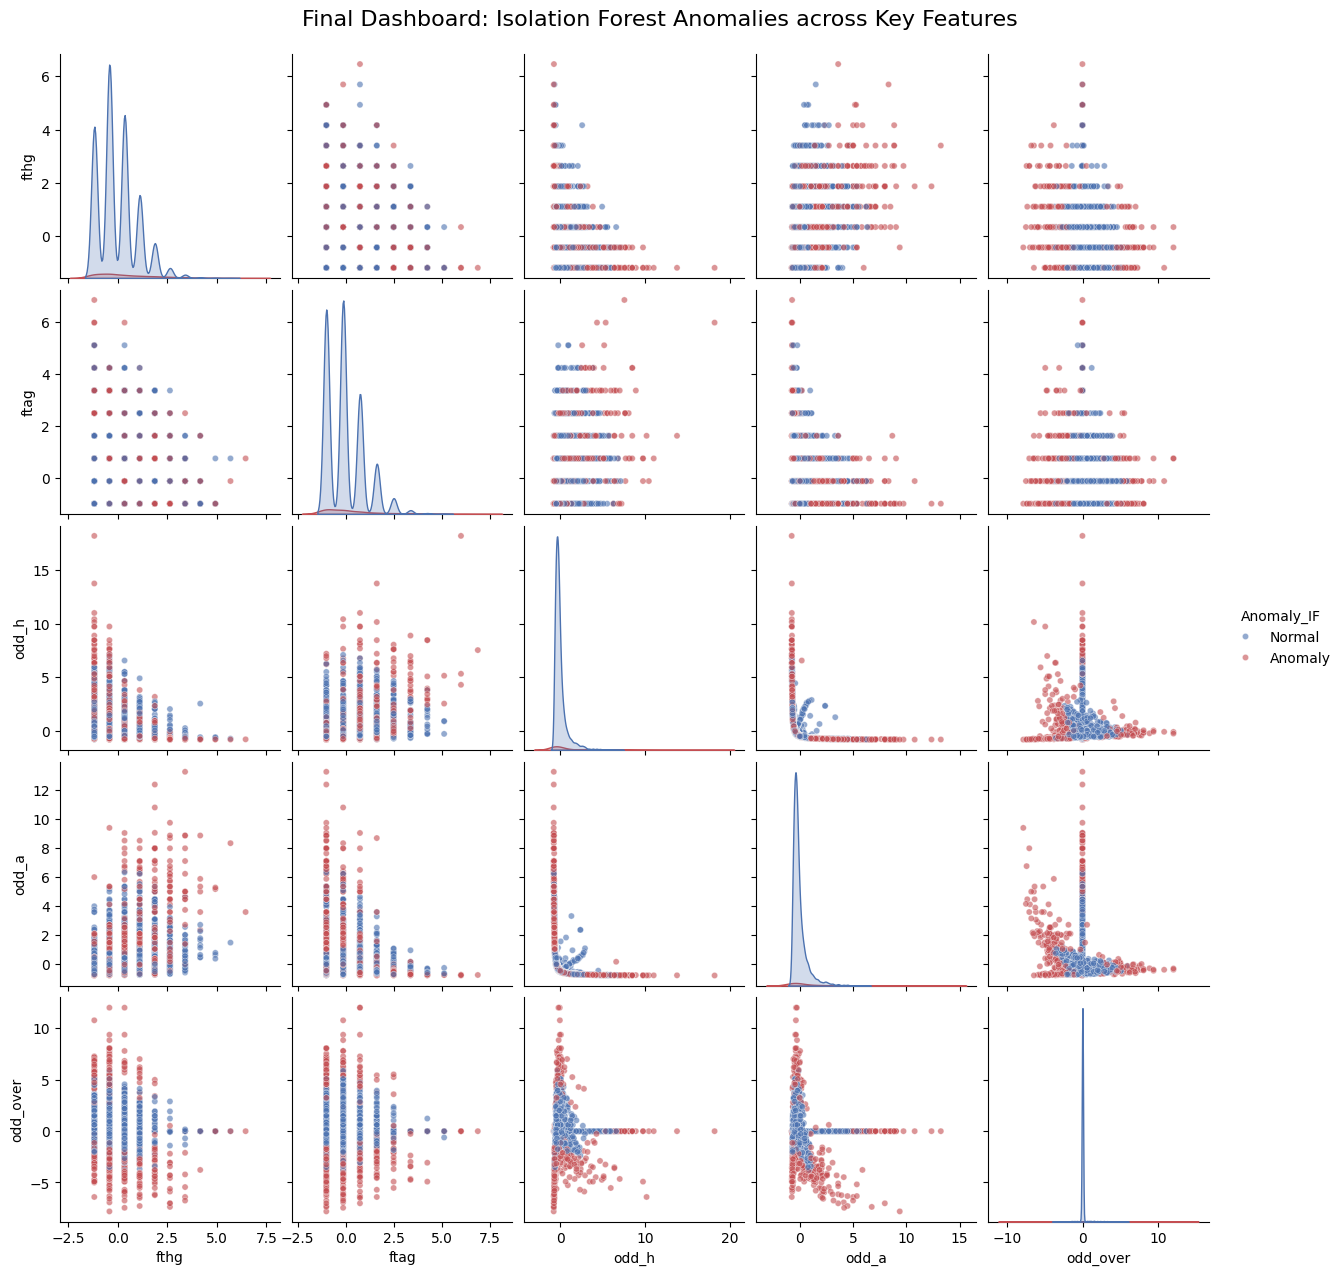

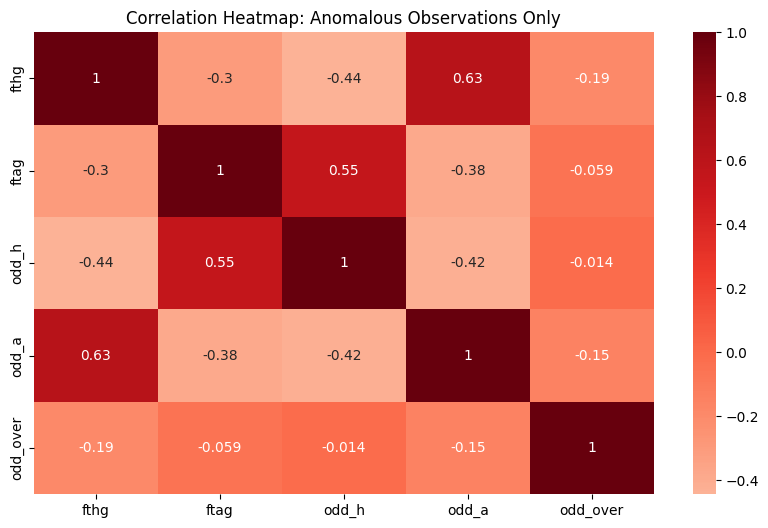

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

dashboard_df = pd.DataFrame(X_scaled, columns=numeric_df.columns)

dashboard_df['Anomaly_IF'] = iso_anomalies
dashboard_df['Anomaly_IF'] = dashboard_df['Anomaly_IF'].map({True: 'Anomaly', False: 'Normal'})

features_to_plot = ['fthg', 'ftag', 'odd_h', 'odd_a', 'odd_over']

print("Generating Pairplot Dashboard... (This may take a moment)")

plt.figure(figsize=(15, 15))
sns.pairplot(
    dashboard_df,
    vars=features_to_plot,
    hue='Anomaly_IF',
    palette={'Normal': '#4C72B0', 'Anomaly': '#C44E52'},
    plot_kws={'alpha': 0.6, 's': 20},
    diag_kind='kde'
)

plt.suptitle("Final Dashboard: Isolation Forest Anomalies across Key Features", y=1.02, fontsize=16)
plt.show()

plt.figure(figsize=(10, 6))
anomaly_data = dashboard_df[dashboard_df['Anomaly_IF'] == 'Anomaly'][features_to_plot]
if not anomaly_data.empty:
    sns.heatmap(anomaly_data.corr(), annot=True, cmap="Reds", center=0)
    plt.title("Correlation Heatmap: Anomalous Observations Only")
    plt.show()